In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

### 设置GPU
设置GPU为memory_growth模式，它的意思是此时我们需要多少GPU内存就使用多少，不会过多占用。

In [2]:
#如果没有装GPU版本，这部分就不用写，但是如果不用GPU加速计算，使用CPU将会严重限制模型的训练速度
gpus = tf.config.experimental.list_physical_devices('GPU') 
if gpus:
  try:

    for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
    logical_gpus = tf.config.experimental.list_logical_devices('GPU')
    print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
  except RuntimeError as e:

    print(e)

1 Physical GPUs, 1 Logical GPUs


### 加载数据

In [3]:
df = pd.read_csv("./data/Iris.csv")
df.head()

,SepalLengthCmSepalWidthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   SepalLengthCmSepalWidthCm  150 non-null    float64
 1   SepalWidthCm               150 non-null    float64
 2   PetalLengthCm              150 non-null    float64
 3   PetalWidthCm               150 non-null    float64
 4   Species                    150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


看一下有几类

In [5]:
print(df.Species.unique())
print(df.Species.nunique())

['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
3


### 数据预处理
对Species这一列进行one-hot编码,然后加入到DataFrame里

In [6]:
df = df.join(pd.get_dummies(df.Species))
del df["Species"]
df.head()

,SepalLengthCmSepalWidthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Iris-setosa,Iris-versicolor,Iris-virginica
0,5.1,3.5,1.4,0.2,1,0,0
1,4.9,3.0,1.4,0.2,1,0,0
2,4.7,3.2,1.3,0.2,1,0,0
3,4.6,3.1,1.5,0.2,1,0,0
4,5.0,3.6,1.4,0.2,1,0,0


打乱顺序，一定要在划分x, y之前打乱

In [7]:
# 生成该区间的随意唯一索引
index = np.random.permutation(len(df))
# 用生成的乱的索引就能将其打乱了
df = df.iloc[index ,:]

将特征x与标签y分成两部分

In [8]:
x = df.iloc[:, :-3]
y = df.iloc[:, -3:]
x.head(), y.head()

(     SepalLengthCmSepalWidthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
 134                        6.1           2.6            5.6           1.4
 26                         5.0           3.4            1.6           0.4
 129                        7.2           3.0            5.8           1.6
 28                         5.2           3.4            1.4           0.2
 73                         6.1           2.8            4.7           1.2,
      Iris-setosa  Iris-versicolor  Iris-virginica
 134            0                0               1
 26             1                0               0
 129            0                0               1
 28             1                0               0
 73             0                1               0)

看一下特征x与标签y的形状

In [9]:
x.shape, y.shape

((150, 4), (150, 3))

### 构建模型
##### activation激活函数，常用激活函数有：
activation='softmax'；activation='sigmoid'；activation='relu'；activation='tanh'  
##### input_dim输入维度  

##### Dense全连接层，深度学习最常用的层

In [10]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Dense(3, input_dim=4, activation='softmax'))#注意此处，本模型只有一层，第一层与最后一层皆是本层
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 3)                 15        
Total params: 15
Trainable params: 15
Non-trainable params: 0
_________________________________________________________________


在与计算机相关的事物中，参数一般取2的n次方，如2，4，6，8……，  
但第一层input_shape必须与输入（x）大小一致，本实验中为4，  
最后一层节点数必须与输出（类别数量）一致，本实验中为3

### 编译模型
optimizer优化器  
loss损失函数  
metrics评价函数

In [11]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy', # 注意目标数据一定是one-hot编码的,才用这个计算softmax交叉熵
    metrics=['acc']
)

### 开始训练

In [12]:
history = model.fit(x, y, epochs=300, verbose=1) #verbose日志显示模式

Train on 150 samples
Epoch 1/300
150/150 [==============================] - 1s 4ms/sample - loss: 6.4274 - acc: 0.3333
Epoch 2/300
150/150 [==============================] - 0s 247us/sample - loss: 6.3431 - acc: 0.3333
Epoch 3/300
150/150 [==============================] - 0s 280us/sample - loss: 6.2548 - acc: 0.3333
Epoch 4/300
150/150 [==============================] - 0s 240us/sample - loss: 6.1720 - acc: 0.3333
Epoch 5/300
150/150 [==============================] - 0s 214us/sample - loss: 6.0870 - acc: 0.3333
Epoch 6/300
150/150 [==============================] - 0s 167us/sample - loss: 5.9978 - acc: 0.3333
Epoch 7/300
150/150 [==============================] - 0s 67us/sample - loss: 5.9137 - acc: 0.3333
Epoch 8/300
150/150 [==============================] - 0s 53us/sample - loss: 5.8274 - acc: 0.3333
Epoch 9/300
150/150 [==============================] - 0s 67us/sample - loss: 5.7420 - acc: 0.3333
Epoch 10/300
150/150 [==============================] - 0s 60us/sample - loss: 5.655

150/150 [==============================] - 0s 53us/sample - loss: 1.2874 - acc: 0.3267
Epoch 83/300
150/150 [==============================] - 0s 53us/sample - loss: 1.2735 - acc: 0.3267
Epoch 84/300
150/150 [==============================] - 0s 67us/sample - loss: 1.2619 - acc: 0.3200
Epoch 85/300
150/150 [==============================] - 0s 60us/sample - loss: 1.2502 - acc: 0.3200
Epoch 86/300
150/150 [==============================] - 0s 60us/sample - loss: 1.2395 - acc: 0.3200
Epoch 87/300
150/150 [==============================] - 0s 53us/sample - loss: 1.2290 - acc: 0.2933
Epoch 88/300
150/150 [==============================] - 0s 60us/sample - loss: 1.2196 - acc: 0.2867
Epoch 89/300
150/150 [==============================] - 0s 67us/sample - loss: 1.2105 - acc: 0.2800
Epoch 90/300
150/150 [==============================] - 0s 53us/sample - loss: 1.2024 - acc: 0.2467
Epoch 91/300
150/150 [==============================] - 0s 60us/sample - loss: 1.1936 - acc: 0.2200
Epoch 92/300


150/150 [==============================] - 0s 67us/sample - loss: 0.8333 - acc: 0.5467
Epoch 164/300
150/150 [==============================] - 0s 53us/sample - loss: 0.8301 - acc: 0.5667
Epoch 165/300
150/150 [==============================] - 0s 67us/sample - loss: 0.8267 - acc: 0.5667
Epoch 166/300
150/150 [==============================] - 0s 53us/sample - loss: 0.8234 - acc: 0.5733
Epoch 167/300
150/150 [==============================] - 0s 53us/sample - loss: 0.8200 - acc: 0.5733
Epoch 168/300
150/150 [==============================] - 0s 47us/sample - loss: 0.8167 - acc: 0.5733
Epoch 169/300
150/150 [==============================] - 0s 53us/sample - loss: 0.8134 - acc: 0.5733
Epoch 170/300
150/150 [==============================] - 0s 53us/sample - loss: 0.8102 - acc: 0.5800
Epoch 171/300
150/150 [==============================] - 0s 53us/sample - loss: 0.8070 - acc: 0.5800
Epoch 172/300
150/150 [==============================] - 0s 53us/sample - loss: 0.8040 - acc: 0.5800
Epoc

150/150 [==============================] - 0s 53us/sample - loss: 0.6435 - acc: 0.7267
Epoch 244/300
150/150 [==============================] - 0s 60us/sample - loss: 0.6421 - acc: 0.7333
Epoch 245/300
150/150 [==============================] - 0s 53us/sample - loss: 0.6404 - acc: 0.7267
Epoch 246/300
150/150 [==============================] - 0s 53us/sample - loss: 0.6387 - acc: 0.7333
Epoch 247/300
150/150 [==============================] - 0s 53us/sample - loss: 0.6372 - acc: 0.7267
Epoch 248/300
150/150 [==============================] - 0s 53us/sample - loss: 0.6357 - acc: 0.7333
Epoch 249/300
150/150 [==============================] - 0s 53us/sample - loss: 0.6340 - acc: 0.7333
Epoch 250/300
150/150 [==============================] - 0s 53us/sample - loss: 0.6325 - acc: 0.7333
Epoch 251/300
150/150 [==============================] - 0s 60us/sample - loss: 0.6310 - acc: 0.7333
Epoch 252/300
150/150 [==============================] - 0s 60us/sample - loss: 0.6296 - acc: 0.7333
Epoc

verbose = 0 为不输出  
verbose = 1 为每个epoch输出一行带进度条的记录
verbose = 2 为每个epoch输出一行记录  

### 绘制损失和精度曲线

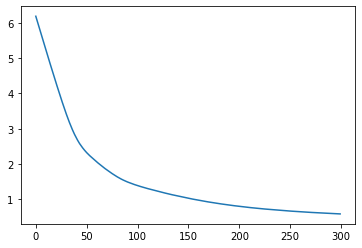

In [27]:
plt.plot(range(300),history.history.get('loss'))

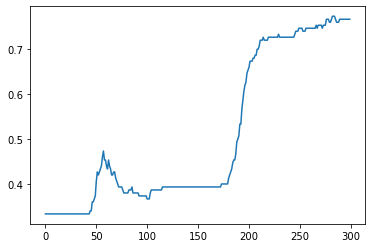

In [28]:
plt.plot(range(300),history.history.get('acc'))